Using device: cuda
Columns : ['Minute', 'IRRIGATION', 'Soil Moisture']
Shape   : (100000, 3)
   Minute  IRRIGATION  Soil Moisture
0       1    0.000004       0.413307
1       2    0.000004       0.413430
2       3    0.000004       0.413525
3       4    0.000004       0.413605
4       5    0.000004       0.413677
5       6    0.000004       0.413742
6       7    0.000004       0.413802
7       8    0.000004       0.413858
8       9    0.000004       0.413911
9      10    0.000004       0.413962

LOOKBACK  : 180 minutes
N_CLUSTERS: 4

── Step 1: Extracting window features for clustering ─
Feature matrix shape: (99821, 10)
Features: mean, std, min, max, range, slope, mean_diff, energy, last_val, mean_irr

── Step 2: Finding optimal K (Elbow + Silhouette) ───
  K=2 | Inertia: 1832.14 | Silhouette: 0.2555
  K=3 | Inertia: 1278.80 | Silhouette: 0.3081
  K=4 | Inertia: 1134.97 | Silhouette: 0.2916
  K=5 | Inertia: 998.93 | Silhouette: 0.2320
  K=6 | Inertia: 905.31 | Silhouette: 0.2207
  K=7

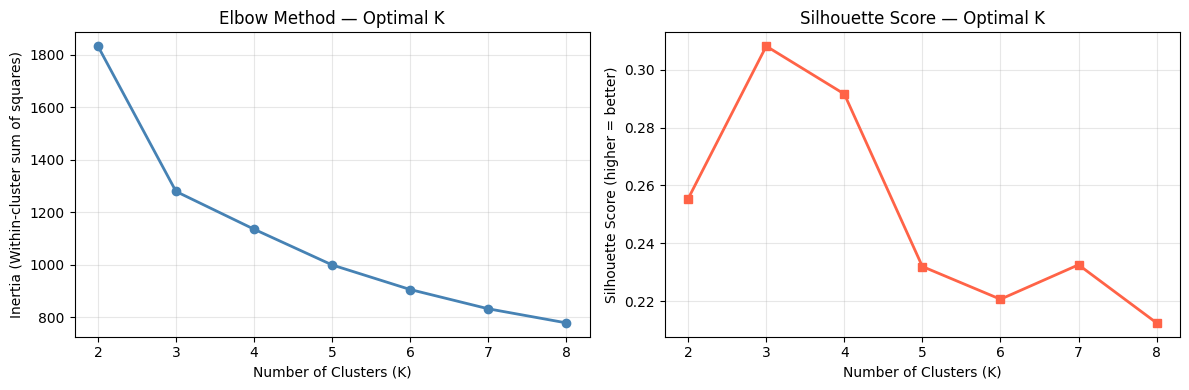

Saved: cluster_selection.png

Best K by Silhouette: 3
Using N_CLUSTERS = 4 (adjust if needed based on plot)

── Step 3: Clustering all windows into 4 clusters ─

Cluster Profiles (Soil Moisture behaviour):
Cluster    Count      Mean SM      Slope        Std          Label
----------------------------------------------------------------------
  C0        15385      0.433612     -0.000024    0.169034     Transitioning
  C1        48071      0.435156     -0.000185    0.210336     Transitioning
  C2        30812      0.435432     0.000304     0.210584     Rising
  C3        5553       0.429772     0.000054     0.113112     Transitioning

── Visualising Clusters ──────────────────────────────


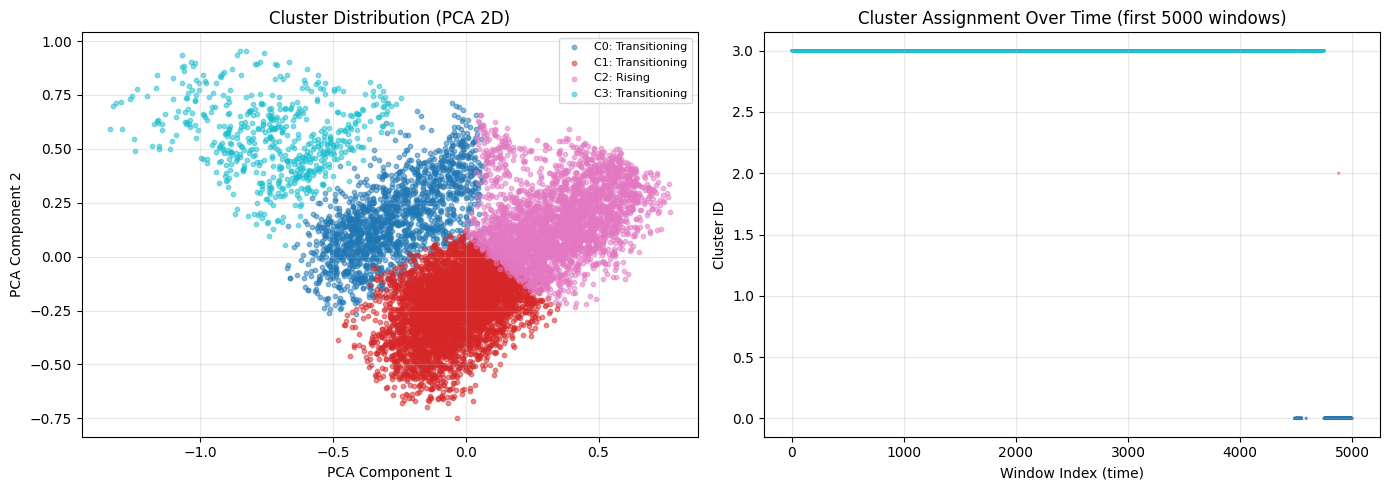

Saved: cluster_visualisation.png

── Cluster Dataset Sizes ─────────────────────────────
  Cluster 0 (Transitioning ): Train= 13055 | Val=  2330
  Cluster 1 (Transitioning ): Train= 37351 | Val= 10720
  Cluster 2 (Rising        ): Train= 24182 | Val=  6629
  Cluster 3 (Transitioning ): Train=  5268 | Val=   285

── Step 6: Training Specialist Transformers ──────────

  ── Cluster 0 (Transitioning) ────────────────
    Epoch   1/75 | Train: 0.011086 | Val: 0.007657 | 11.7s
    Epoch  10/75 | Train: 0.006339 | Val: 0.006002 | 11.4s
    Epoch  20/75 | Train: 0.005599 | Val: 0.005703 | 11.2s
    Epoch  30/75 | Train: 0.005359 | Val: 0.005791 | 11.2s
    Epoch  40/75 | Train: 0.005214 | Val: 0.005795 | 11.1s
    Epoch  50/75 | Train: 0.004992 | Val: 0.005344 | 11.1s
    Epoch  60/75 | Train: 0.004901 | Val: 0.005328 | 11.1s
    Epoch  70/75 | Train: 0.004867 | Val: 0.005258 | 11.1s
  Best Val Loss: 0.005258

  ── Cluster 1 (Transitioning) ────────────────
    Epoch   1/75 | Train: 0.009232 

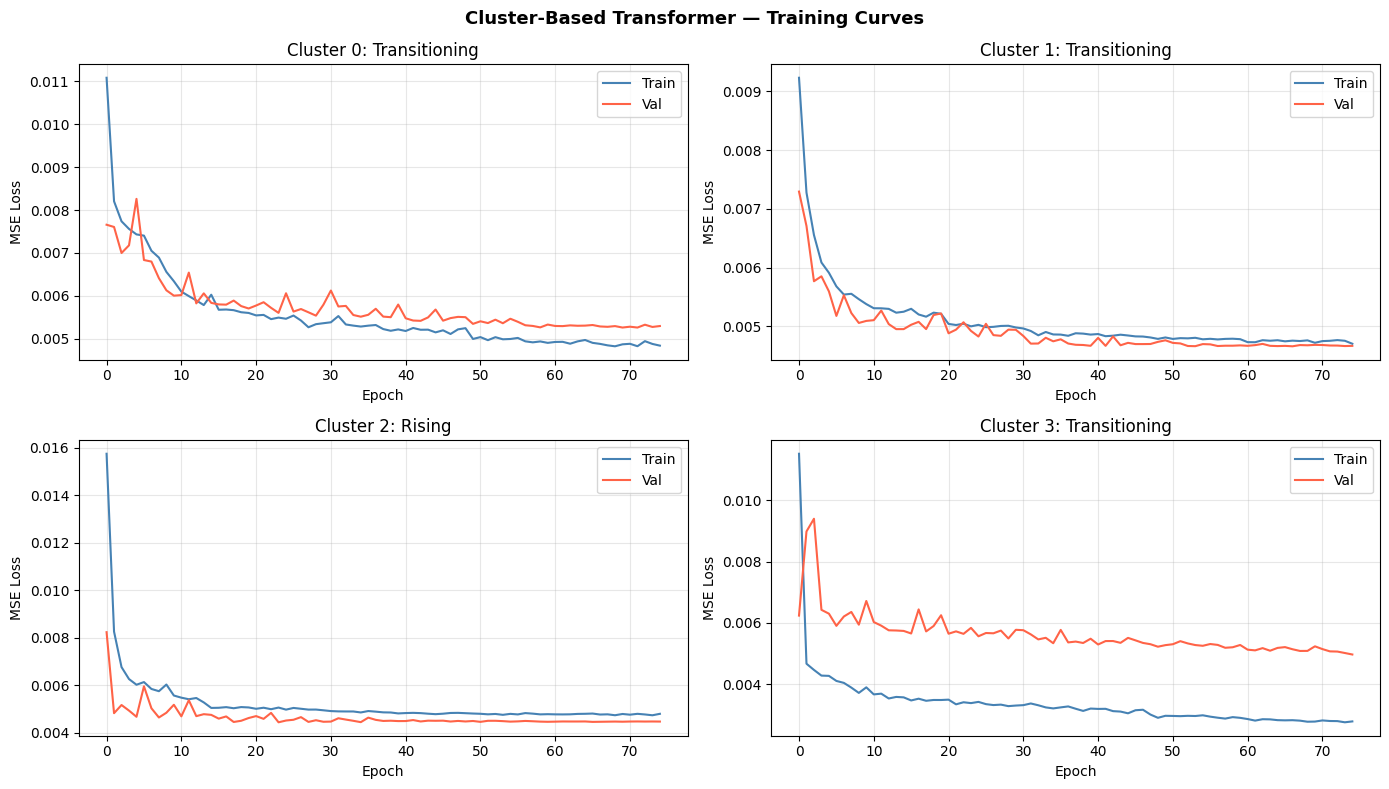

Saved: cluster_training_curves.png

── Step 8: Evaluation on Validation Set ─────────────

  Cluster 0 (Transitioning) — n=2330
    RMSE : 0.00267649
    MAE  : 0.00084341
    MAPE : 0.1932 %
    R²   : 0.814110
    MASE : 0.834177

  Cluster 1 (Transitioning) — n=10720
    RMSE : 0.00252367
    MAE  : 0.00078781
    MAPE : 0.1808 %
    R²   : 0.712469
    MASE : 0.631294

  Cluster 2 (Rising) — n=6629
    RMSE : 0.00246615
    MAE  : 0.00085333
    MAPE : 0.1948 %
    R²   : 0.832208
    MASE : 0.457396

  Cluster 3 (Transitioning) — n=285
    RMSE : 0.00260218
    MAE  : 0.00114261
    MAPE : 0.2626 %
    R²   : 0.762568
    MASE : 1.165851

── Overall Validation Metrics (all clusters combined) ─
  MSE          : 0.00000637
  RMSE         : 0.00252430
  MAE          : 0.00082112
  MAPE         : 0.1881 %
  Standard R²  : 0.892421
  MASE         : 0.577005
  ✅ Model beats naive baseline (MASE < 1)
  ⚠️  Moderate fit (R² 0.7–0.9)

── Dynamic R² (Rolling 1-day window) ────────────────
 

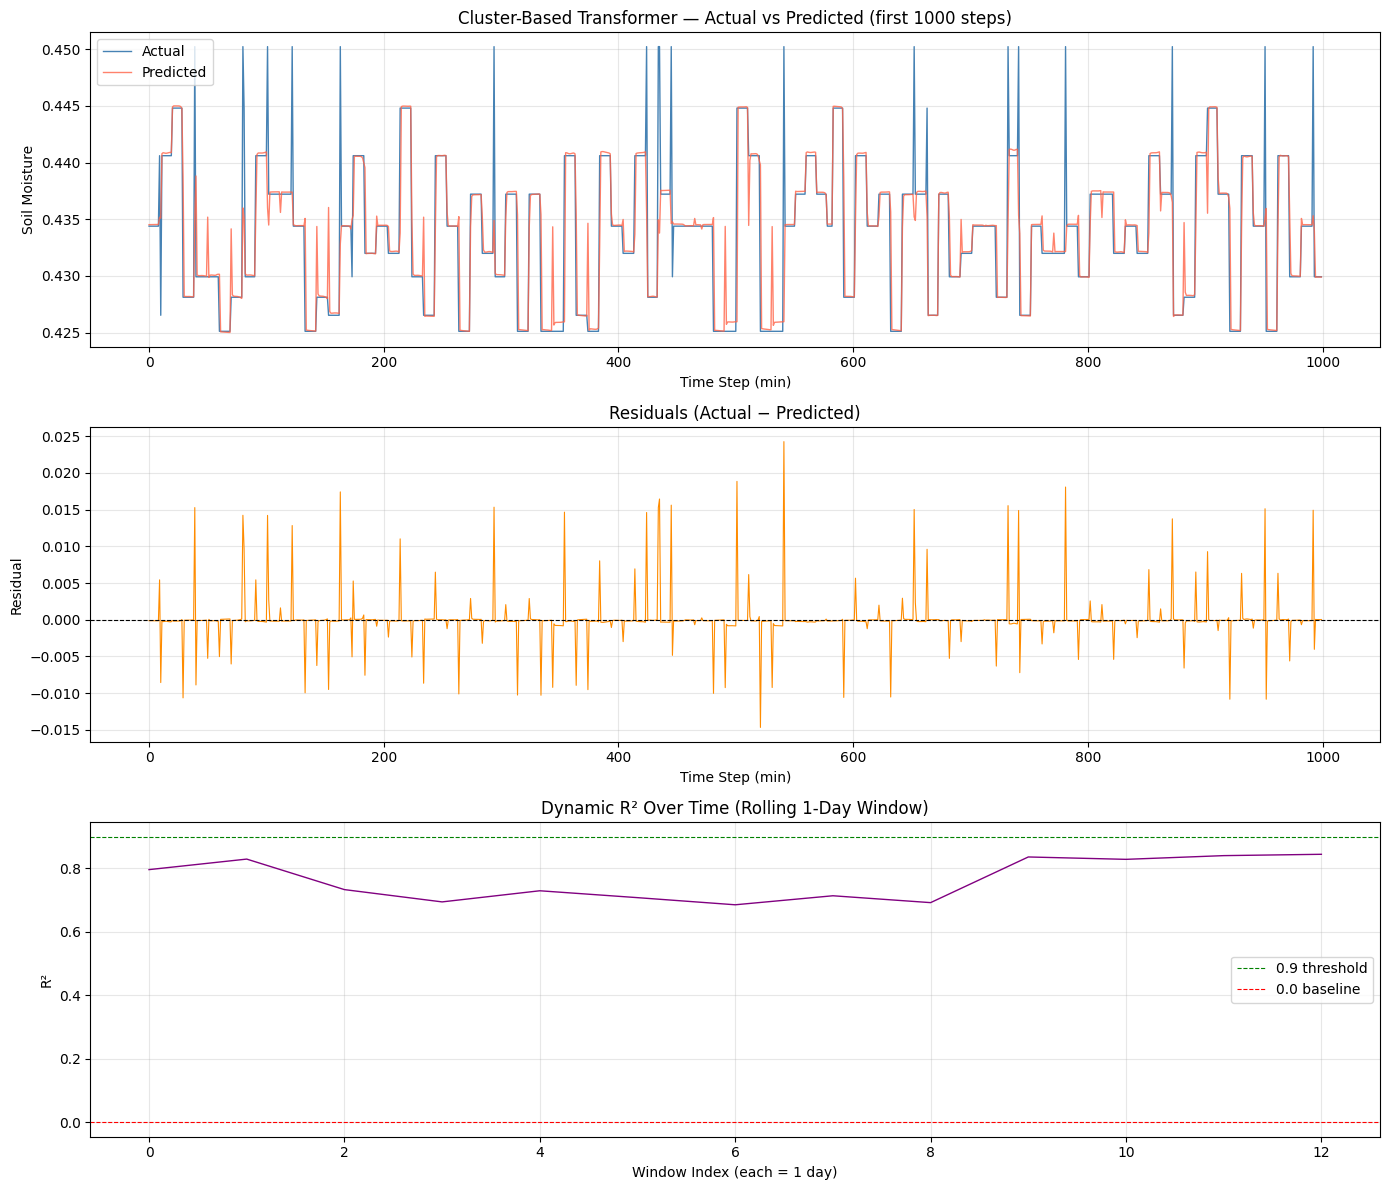

Saved: cluster_evaluation.png

── Step 9: Generating 14,400-step Forecast ──────────
  Day  1 complete | Cluster usage: C0:60 | C1:63 | C2:7 | C3:1310
  Day  2 complete | Cluster usage: C0:0 | C1:0 | C2:0 | C3:1440
  Day  3 complete | Cluster usage: C0:0 | C1:0 | C2:0 | C3:1440
  Day  4 complete | Cluster usage: C0:0 | C1:0 | C2:0 | C3:1440
  Day  5 complete | Cluster usage: C0:0 | C1:0 | C2:0 | C3:1440
  Day  6 complete | Cluster usage: C0:0 | C1:0 | C2:0 | C3:1440
  Day  7 complete | Cluster usage: C0:0 | C1:0 | C2:0 | C3:1440
  Day  8 complete | Cluster usage: C0:0 | C1:0 | C2:0 | C3:1440
  Day  9 complete | Cluster usage: C0:0 | C1:0 | C2:0 | C3:1440
  Day 10 complete | Cluster usage: C0:0 | C1:0 | C2:0 | C3:1440

Forecast Summary (Soil Moisture):
  Min  : 0.433334
  Max  : 0.435414
  Mean : 0.434176
  Std  : 0.000069

Forecast Stability Score : 0.0088  (1.0 = ideal)
Smoothing Window Applied : 5 steps


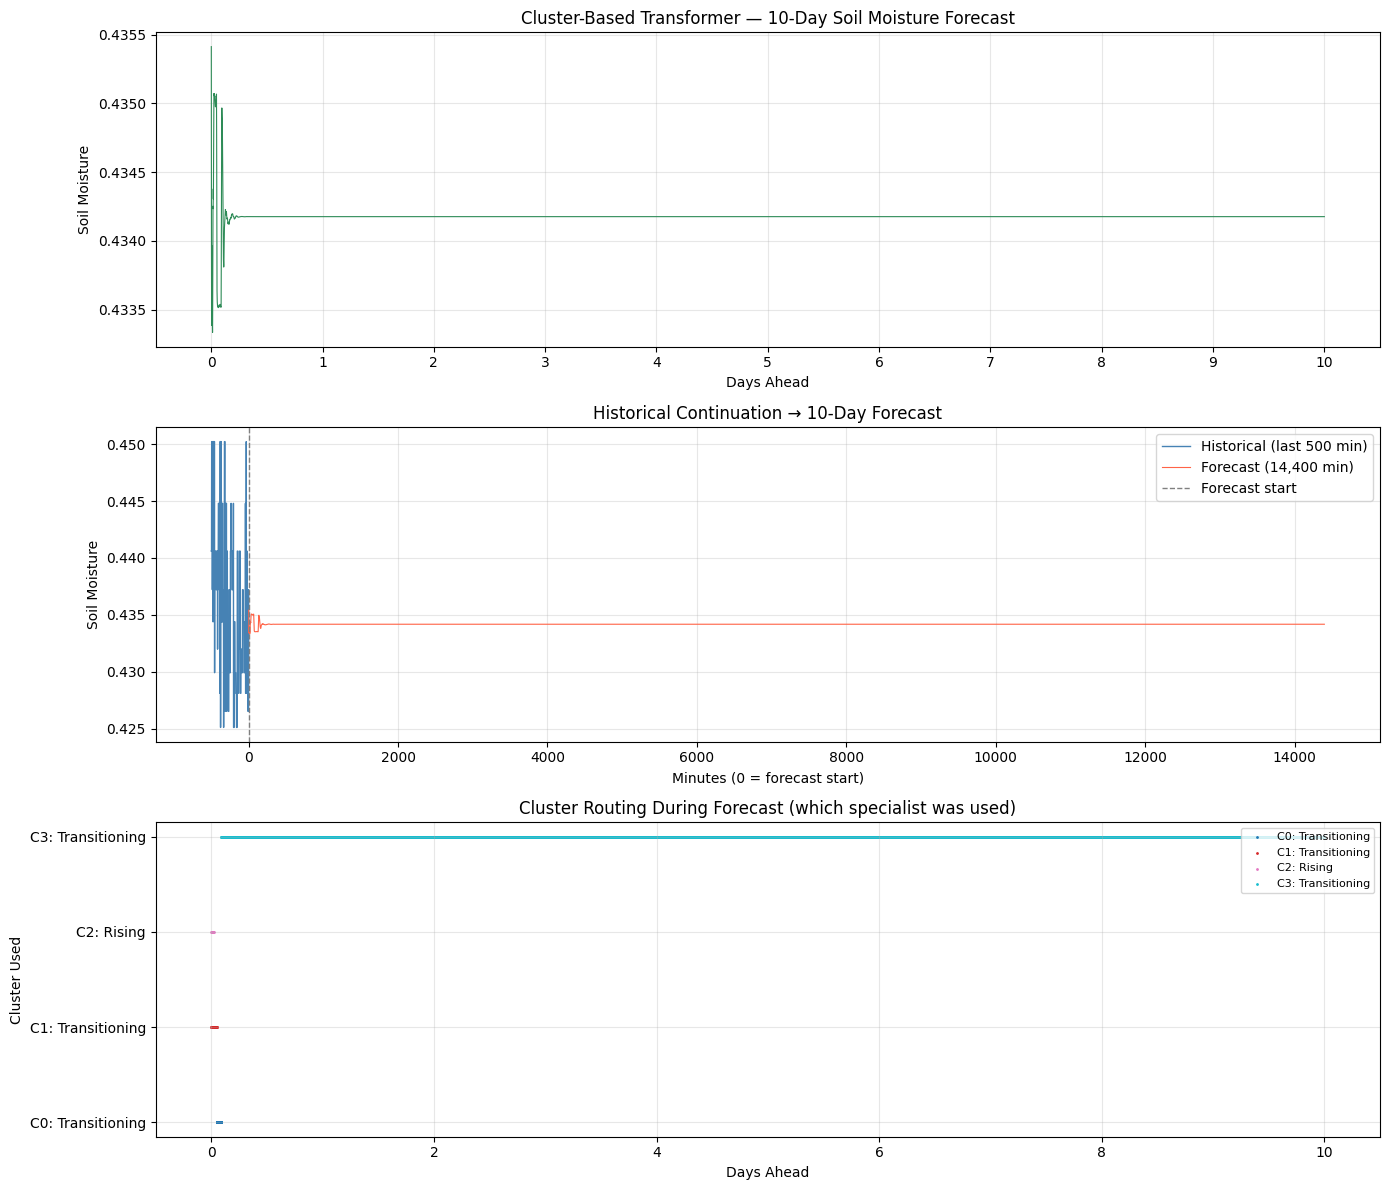

Saved: cluster_forecast_10days.png

── Final Model Comparison ────────────────────────────
Metric                    Vanilla     PatchTST   iTransformer   Cluster-Based
---------------------------------------------------------------------------
  RMSE                   0.002536     0.002589       0.002572        0.002524 ✅
  MAE                    0.000899     0.001009       0.001104        0.000821 ✅
  MAPE (%)               0.205800     0.231400       0.252600        0.188071 ✅
  R²                     0.891400     0.887300       0.888800        0.892421 ✅
  MASE                   1.034000     1.159000       1.269000        0.577005 ✅
  Dyn R² Mean            0.890700     0.886000       0.887800        0.763886 ✅

Forecast saved to: forecast_14400_cluster_transformer.csv
   Minute  Forecast_SM  Cluster_Used
0       1     0.435414             2
1       2     0.434006             1
2       3     0.433975             1
3       4     0.433571             1
4       5     0.433447         

In [ ]:
# ============================================================
#  CLUSTER-BASED TRANSFORMER — Soil Moisture Forecasting
#  Google Colab Ready | Unsupervised Clustering + Specialist
#  Transformers per Cluster | Autoregressive 14400-step Forecast
# ============================================================

# ── 0. INSTALL / IMPORTS ────────────────────────────────────
!pip install openpyxl scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, mean_squared_error,
                             mean_absolute_error)
from sklearn.decomposition import PCA
import math
import time
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_excel('/content/Final_Dataset.xlsx', engine='openpyxl')
df.columns = df.columns.str.strip()

print(f"Columns : {df.columns.tolist()}")
print(f"Shape   : {df.shape}")
print(df.head(10))


# ============================================================
# 2. PREPROCESSING
# ============================================================
features = df[["IRRIGATION", "Soil Moisture"]].values   # (N, 2)

scaler    = MinMaxScaler()
scaled    = scaler.fit_transform(features)

sm_scaler = MinMaxScaler()
sm_scaler.fit(features[:, 1].reshape(-1, 1))

# ── Hyperparameters ─────────────────────────────────────────
LOOKBACK     = 180
HORIZON      = 1
BATCH_SIZE   = 32
EPOCHS       = 75
LR           = 3e-4
D_MODEL      = 128
NHEAD        = 8
NUM_LAYERS   = 4
DIM_FF       = 256
DROPOUT      = 0.05
TRAIN_SPLIT  = 0.8
N_CLUSTERS   = 4

print(f"\nLOOKBACK  : {LOOKBACK} minutes")
print(f"N_CLUSTERS: {N_CLUSTERS}")


# ============================================================
# 3. STEP 1 — FEATURE EXTRACTION FOR CLUSTERING
# ============================================================
# Extract statistical features from each sliding window
# These features describe the "behaviour" of that window
# Used by K-Means to group similar behavioural patterns

print("\n── Step 1: Extracting window features for clustering ─")

CLUSTER_WINDOW = LOOKBACK   # same size as transformer lookback

def extract_features(data_scaled, window_size):
    """
    For each window, extract 10 statistical features:
    mean, std, min, max, range, slope (trend),
    mean_diff (rate of change), skewness, energy, last_value
    These capture the 'behaviour' of each window.
    """
    sm   = data_scaled[:, 1]   # Soil Moisture only for clustering
    irr  = data_scaled[:, 0]   # Irrigation
    n    = len(sm) - window_size + 1
    feats = []

    for i in range(n):
        w     = sm[i : i + window_size]
        irr_w = irr[i : i + window_size]

        mean_sm    = np.mean(w)
        std_sm     = np.std(w)
        min_sm     = np.min(w)
        max_sm     = np.max(w)
        range_sm   = max_sm - min_sm
        # Linear slope (trend direction: positive=rising, negative=dropping)
        slope      = np.polyfit(np.arange(window_size), w, 1)[0]
        mean_diff  = np.mean(np.diff(w))           # average rate of change
        energy     = np.sum(w ** 2) / window_size  # signal energy
        last_val   = w[-1]                         # current moisture level
        mean_irr   = np.mean(irr_w)                # irrigation context

        feats.append([mean_sm, std_sm, min_sm, max_sm, range_sm,
                      slope, mean_diff, energy, last_val, mean_irr])

    return np.array(feats)

all_features = extract_features(scaled, CLUSTER_WINDOW)
print(f"Feature matrix shape: {all_features.shape}")
print(f"Features: mean, std, min, max, range, slope, mean_diff, energy, last_val, mean_irr")

# Normalise features for clustering
feat_scaler   = MinMaxScaler()
feats_scaled  = feat_scaler.fit_transform(all_features)


# ============================================================
# 4. STEP 2 — FIND OPTIMAL NUMBER OF CLUSTERS
# ============================================================
print("\n── Step 2: Finding optimal K (Elbow + Silhouette) ───")

# Use a subset for speed (every 10th window)
sample_idx   = np.arange(0, len(feats_scaled), 10)
feats_sample = feats_scaled[sample_idx]

inertias     = []
sil_scores   = []
K_range      = range(2, 9)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(feats_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(feats_sample, lbl))
    print(f"  K={k} | Inertia: {km.inertia_:.2f} | Silhouette: {sil_scores[-1]:.4f}")

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-cluster sum of squares)")
axes[0].set_title("Elbow Method — Optimal K")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, marker='s', color='tomato', linewidth=2)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].set_title("Silhouette Score — Optimal K")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_selection.png", dpi=150)
plt.show()
print("Saved: cluster_selection.png")

# Auto-select best K by silhouette
best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nBest K by Silhouette: {best_k}")
print(f"Using N_CLUSTERS = {N_CLUSTERS} (adjust if needed based on plot)")


# ============================================================
# 5. STEP 3 — ASSIGN CLUSTERS TO ALL WINDOWS
# ============================================================
print(f"\n── Step 3: Clustering all windows into {N_CLUSTERS} clusters ─")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
all_labels = kmeans.fit_predict(feats_scaled)

# Cluster statistics — understand what each cluster represents
print("\nCluster Profiles (Soil Moisture behaviour):")
print(f"{'Cluster':<10} {'Count':<10} {'Mean SM':<12} {'Slope':<12} {'Std':<12} {'Label'}")
print("-" * 70)

cluster_labels_desc = []
for c in range(N_CLUSTERS):
    idx     = np.where(all_labels == c)[0]
    c_feats = all_features[idx]
    mean_sm = sm_scaler.inverse_transform([[c_feats[:, 0].mean()]])[0][0]
    slope   = c_feats[:, 5].mean()
    std_sm  = c_feats[:, 1].mean()
    count   = len(idx)

    # Auto-label based on slope and std
    if slope > 0.0003:
        desc = "Rising"
    elif slope < -0.0003:
        desc = "Dropping"
    elif std_sm < 0.002:
        desc = "Stable"
    else:
        desc = "Transitioning"

    cluster_labels_desc.append(desc)
    print(f"  C{c:<8} {count:<10} {mean_sm:<12.6f} {slope:<12.6f} {std_sm:<12.6f} {desc}")


# ============================================================
# 6. VISUALISE CLUSTERS (PCA + Time plot)
# ============================================================
print("\n── Visualising Clusters ──────────────────────────────")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = cm.tab10(np.linspace(0, 1, N_CLUSTERS))

# PCA 2D scatter
pca    = PCA(n_components=2)
pca_2d = pca.fit_transform(feats_scaled[sample_idx])

for c in range(N_CLUSTERS):
    mask = all_labels[sample_idx] == c
    axes[0].scatter(pca_2d[mask, 0], pca_2d[mask, 1],
                    c=[colors[c]], label=f"C{c}: {cluster_labels_desc[c]}",
                    alpha=0.5, s=10)
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].set_title("Cluster Distribution (PCA 2D)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Cluster assignment over time (first 5000 windows)
t_range = min(5000, len(all_labels))
axes[1].scatter(range(t_range), all_labels[:t_range],
                c=[colors[l] for l in all_labels[:t_range]],
                s=2, alpha=0.7)
axes[1].set_xlabel("Window Index (time)")
axes[1].set_ylabel("Cluster ID")
axes[1].set_title("Cluster Assignment Over Time (first 5000 windows)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_visualisation.png", dpi=150)
plt.show()
print("Saved: cluster_visualisation.png")


# ============================================================
# 7. STEP 4 — DATASET PER CLUSTER
# ============================================================
# Each cluster gets its own dataset of windows

class ClusterDataset(Dataset):
    """
    Dataset containing only windows belonging to a specific cluster.
    src : (LOOKBACK, 2)  — past [irrigation, soil_moisture]
    tgt : (1,)           — next soil_moisture (normalised)
    """
    def __init__(self, scaled_data, window_indices, lookback, horizon):
        self.scaled_data    = scaled_data
        self.window_indices = window_indices
        self.lookback       = lookback
        self.horizon        = horizon

    def __len__(self):
        valid = [
            idx for idx in self.window_indices
            if idx + self.lookback + self.horizon <= len(self.scaled_data)
        ]
        self.window_indices = np.array(valid)
        return len(self.window_indices)

    def __getitem__(self, i):
        idx = self.window_indices[i]
        src = self.scaled_data[idx : idx + self.lookback]
        tgt = self.scaled_data[idx + self.lookback : idx + self.lookback + self.horizon, 1]
        return (torch.tensor(src, dtype=torch.float32),
                torch.tensor(tgt, dtype=torch.float32))


# Split indices for train/val
split_idx  = int(len(all_labels) * TRAIN_SPLIT)

cluster_loaders = {}   # {cluster_id: (train_loader, val_loader, train_count, val_count)}

print("\n── Cluster Dataset Sizes ─────────────────────────────")
for c in range(N_CLUSTERS):
    c_indices      = np.where(all_labels == c)[0]
    train_idx      = c_indices[c_indices < split_idx]
    val_idx        = c_indices[c_indices >= split_idx]

    train_ds = ClusterDataset(scaled, train_idx, LOOKBACK, HORIZON)
    val_ds   = ClusterDataset(scaled, val_idx,   LOOKBACK, HORIZON)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, drop_last=False)

    cluster_loaders[c] = (train_loader, val_loader, len(train_ds), len(val_ds))
    print(f"  Cluster {c} ({cluster_labels_desc[c]:<14}): "
          f"Train={len(train_ds):6d} | Val={len(val_ds):6d}")


# ============================================================
# 8. STEP 5 — TRANSFORMER MODEL (one per cluster)
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class ClusterTransformer(nn.Module):
    """
    Vanilla Transformer — one instance trained per cluster.
    Each model specialises in the behaviour of its cluster:
      C0: Expert at Rising moisture patterns
      C1: Expert at Stable moisture patterns
      C2: Expert at Dropping moisture patterns
      C3: Expert at Transitioning patterns
    """
    def __init__(self, input_dim=2, d_model=D_MODEL, nhead=NHEAD,
                 num_layers=NUM_LAYERS, dim_ff=DIM_FF,
                 dropout=DROPOUT, horizon=HORIZON, cluster_id=0):
        super().__init__()
        self.cluster_id  = cluster_id
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.pos_enc     = PositionalEncoding(d_model, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True
        )
        self.encoder     = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.output_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, horizon)
        )

    def forward(self, src):
        x   = self.input_proj(src)
        x   = self.pos_enc(x)
        x   = self.encoder(x)
        out = self.output_head(x[:, -1, :])
        return out


# ============================================================
# 9. STEP 6 — TRAIN ONE TRANSFORMER PER CLUSTER
# ============================================================
print("\n── Step 6: Training Specialist Transformers ──────────")

cluster_models      = {}
cluster_train_hist  = {}
cluster_val_hist    = {}

for c in range(N_CLUSTERS):
    print(f"\n  ── Cluster {c} ({cluster_labels_desc[c]}) ────────────────")

    train_loader, val_loader, n_train, n_val = cluster_loaders[c]

    if n_train < BATCH_SIZE:
        print(f"  ⚠️  Cluster {c} has too few samples ({n_train}), skipping training.")
        cluster_models[c] = None
        continue

    model     = ClusterTransformer(cluster_id=c).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    best_val  = float("inf")
    t_losses, v_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        # Train
        model.train()
        run_loss = 0.0
        for src, tgt in train_loader:
            src, tgt = src.to(device), tgt.to(device)
            optimizer.zero_grad()
            pred = model(src)
            loss = criterion(pred, tgt)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            run_loss += loss.item()
        train_loss = run_loss / len(train_loader)

        # Validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                val_loss += criterion(model(src), tgt).item()
        val_loss /= max(len(val_loader), 1)

        scheduler.step(val_loss)
        t_losses.append(train_loss)
        v_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), f"best_cluster_{c}.pt")

        if epoch % 10 == 0 or epoch == 1:
            print(f"    Epoch {epoch:3d}/{EPOCHS} | "
                  f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
                  f"{time.time()-t0:.1f}s")

    print(f"  Best Val Loss: {best_val:.6f}")

    # Load best weights
    model.load_state_dict(torch.load(f"best_cluster_{c}.pt"))
    cluster_models[c]     = model
    cluster_train_hist[c] = t_losses
    cluster_val_hist[c]   = v_losses


# ============================================================
# 10. PLOT TRAINING CURVES (all clusters)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for c in range(N_CLUSTERS):
    if c not in cluster_train_hist:
        continue
    axes[c].plot(cluster_train_hist[c], label="Train", color="steelblue")
    axes[c].plot(cluster_val_hist[c],   label="Val",   color="tomato")
    axes[c].set_title(f"Cluster {c}: {cluster_labels_desc[c]}")
    axes[c].set_xlabel("Epoch")
    axes[c].set_ylabel("MSE Loss")
    axes[c].legend()
    axes[c].grid(True, alpha=0.3)

plt.suptitle("Cluster-Based Transformer — Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cluster_training_curves.png", dpi=150)
plt.show()
print("Saved: cluster_training_curves.png")


# ============================================================
# 11. STEP 7 — CLUSTER ROUTING FUNCTION
# ============================================================
def get_cluster(window_scaled):
    """
    Given a new window of scaled data (LOOKBACK, 2),
    extract features and determine which cluster it belongs to.
    Returns cluster_id (int).
    """
    w       = window_scaled[:, 1]           # Soil Moisture
    irr_w   = window_scaled[:, 0]           # Irrigation
    L       = len(w)

    mean_sm  = np.mean(w)
    std_sm   = np.std(w)
    min_sm   = np.min(w)
    max_sm   = np.max(w)
    range_sm = max_sm - min_sm
    slope    = np.polyfit(np.arange(L), w, 1)[0]
    mean_diff= np.mean(np.diff(w))
    energy   = np.sum(w ** 2) / L
    last_val = w[-1]
    mean_irr = np.mean(irr_w)

    feat = np.array([[mean_sm, std_sm, min_sm, max_sm, range_sm,
                      slope, mean_diff, energy, last_val, mean_irr]])
    feat_norm = feat_scaler.transform(feat)
    return int(kmeans.predict(feat_norm)[0])


# ============================================================
# 12. STEP 8 — EVALUATION ON VALIDATION SET (per cluster + overall)
# ============================================================
print("\n── Step 8: Evaluation on Validation Set ─────────────")

all_preds_combined   = []
all_targets_combined = []
cluster_metrics      = {}

for c in range(N_CLUSTERS):
    model = cluster_models.get(c)
    if model is None:
        continue

    _, val_loader, _, n_val = cluster_loaders[c]
    if n_val == 0:
        continue

    model.eval()
    c_preds, c_targets = [], []

    with torch.no_grad():
        for src, tgt in val_loader:
            src    = src.to(device)
            pred   = model(src).cpu().numpy()
            c_preds.append(pred)
            c_targets.append(tgt.numpy())

    c_preds   = np.concatenate(c_preds,   axis=0).reshape(-1, 1)
    c_targets = np.concatenate(c_targets, axis=0).reshape(-1, 1)

    p_inv = sm_scaler.inverse_transform(c_preds).flatten()
    t_inv = sm_scaler.inverse_transform(c_targets).flatten()

    all_preds_combined.extend(p_inv)
    all_targets_combined.extend(t_inv)

    mse  = mean_squared_error(t_inv, p_inv)
    mae  = mean_absolute_error(t_inv, p_inv)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((t_inv - p_inv) / (t_inv + 1e-8))) * 100
    ss_r = np.sum((t_inv - p_inv) ** 2)
    ss_t = np.sum((t_inv - t_inv.mean()) ** 2)
    r2   = 1 - (ss_r / (ss_t + 1e-8))
    naive_mae = np.mean(np.abs(np.diff(t_inv)))
    mase = mae / (naive_mae + 1e-8)

    cluster_metrics[c] = dict(mse=mse, rmse=rmse, mae=mae,
                               mape=mape, r2=r2, mase=mase)

    print(f"\n  Cluster {c} ({cluster_labels_desc[c]}) — n={n_val}")
    print(f"    RMSE : {rmse:.8f}")
    print(f"    MAE  : {mae:.8f}")
    print(f"    MAPE : {mape:.4f} %")
    print(f"    R²   : {r2:.6f}")
    print(f"    MASE : {mase:.6f}")

# ── Overall metrics ──────────────────────────────────────────
all_p = np.array(all_preds_combined)
all_t = np.array(all_targets_combined)

overall_mse  = mean_squared_error(all_t, all_p)
overall_mae  = mean_absolute_error(all_t, all_p)
overall_rmse = np.sqrt(overall_mse)
overall_mape = np.mean(np.abs((all_t - all_p) / (all_t + 1e-8))) * 100
ss_r = np.sum((all_t - all_p) ** 2)
ss_t = np.sum((all_t - all_t.mean()) ** 2)
overall_r2   = 1 - (ss_r / (ss_t + 1e-8))
naive_mae    = np.mean(np.abs(np.diff(all_t)))
overall_mase = overall_mae / (naive_mae + 1e-8)

print(f"\n── Overall Validation Metrics (all clusters combined) ─")
print(f"  MSE          : {overall_mse:.8f}")
print(f"  RMSE         : {overall_rmse:.8f}")
print(f"  MAE          : {overall_mae:.8f}")
print(f"  MAPE         : {overall_mape:.4f} %")
print(f"  Standard R²  : {overall_r2:.6f}")
print(f"  MASE         : {overall_mase:.6f}")

if overall_mase < 1.0:
    print(f"  ✅ Model beats naive baseline (MASE < 1)")
else:
    print(f"  ⚠️  Model worse than naive baseline (MASE > 1)")

if overall_r2 > 0.9:
    print(f"  ✅ Strong fit (R² > 0.9)")
elif overall_r2 > 0.7:
    print(f"  ⚠️  Moderate fit (R² 0.7–0.9)")
else:
    print(f"  ❌ Weak fit (R² < 0.7)")

# ── Dynamic R² ───────────────────────────────────────────────
window_size = 1440
dynamic_r2  = []
for i in range(0, len(all_t) - window_size, window_size):
    yt = all_t[i : i + window_size]
    yp = all_p[i : i + window_size]
    ss_r_w = np.sum((yt - yp) ** 2)
    ss_t_w = np.sum((yt - yt.mean()) ** 2)
    dynamic_r2.append(1 - (ss_r_w / (ss_t_w + 1e-8)))

dynamic_r2 = np.array(dynamic_r2)
print(f"\n── Dynamic R² (Rolling 1-day window) ────────────────")
print(f"  Mean  : {dynamic_r2.mean():.6f}")
print(f"  Min   : {dynamic_r2.min():.6f}")
print(f"  Max   : {dynamic_r2.max():.6f}")

# ── Evaluation plots ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Actual vs Predicted
axes[0].plot(all_t[:1000], label="Actual",    color="steelblue", linewidth=1)
axes[0].plot(all_p[:1000], label="Predicted", color="tomato",    linewidth=1, alpha=0.8)
axes[0].set_title("Cluster-Based Transformer — Actual vs Predicted (first 1000 steps)")
axes[0].set_xlabel("Time Step (min)")
axes[0].set_ylabel("Soil Moisture")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = all_t[:1000] - all_p[:1000]
axes[1].plot(residuals, color="darkorange", linewidth=0.8)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Residuals (Actual − Predicted)")
axes[1].set_xlabel("Time Step (min)")
axes[1].set_ylabel("Residual")
axes[1].grid(True, alpha=0.3)

# Plot 3: Dynamic R²
axes[2].plot(dynamic_r2, color="purple", linewidth=1)
axes[2].axhline(0.9, color="green", linestyle="--", linewidth=0.8, label="0.9 threshold")
axes[2].axhline(0.0, color="red",   linestyle="--", linewidth=0.8, label="0.0 baseline")
axes[2].set_title("Dynamic R² Over Time (Rolling 1-Day Window)")
axes[2].set_xlabel("Window Index (each = 1 day)")
axes[2].set_ylabel("R²")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_evaluation.png", dpi=150)
plt.show()
print("Saved: cluster_evaluation.png")


# ============================================================
# 13. STEP 9 — AUTOREGRESSIVE FORECAST (14,400 steps)
# ============================================================
print("\n── Step 9: Generating 14,400-step Forecast ──────────")

seed_window        = scaled[-LOOKBACK:].copy()
mean_irr_scaled    = scaled[:, 0].mean()
forecast_sm_scaled = []
forecast_clusters  = []

# ── Smoothing parameters ─────────────────────────────────────
SMOOTH_WINDOW   = 5       # rolling average window for transition smoothing
prev_cluster    = None    # track previous cluster for handoff detection
raw_forecast    = []      # store raw predictions before smoothing

with torch.no_grad():
    window = seed_window.copy()

    for step in range(14400):
        # Route to correct cluster
        c_id  = get_cluster(window)

        # ── Transition dampening ─────────────────────────────
        # When cluster changes, blend prediction with last prediction
        # to avoid abrupt jumps at handoff boundaries
        if prev_cluster is not None and c_id != prev_cluster:
            # Cluster switched — get prediction from BOTH old and new cluster
            model_new  = cluster_models.get(c_id)
            model_prev = cluster_models.get(prev_cluster)

            if model_new is None:
                model_new = cluster_models.get(0)
            if model_prev is None:
                model_prev = cluster_models.get(0)

            src = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

            pred_new  = model_new(src).cpu().numpy()[0, 0]
            pred_prev = model_prev(src).cpu().numpy()[0, 0]

            # Blend: 70% new cluster, 30% old cluster at handoff point
            pred_scaled = 0.7 * pred_new + 0.3 * pred_prev

        else:
            # Same cluster — use specialist directly
            model = cluster_models.get(c_id)
            if model is None:
                model = cluster_models.get(0)

            src         = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
            pred_scaled = model(src).cpu().numpy()[0, 0]

        raw_forecast.append(pred_scaled)
        forecast_clusters.append(c_id)
        prev_cluster = c_id

        new_row = np.array([mean_irr_scaled, pred_scaled])
        window  = np.vstack([window[1:], new_row])

        if (step + 1) % 1440 == 0:
            day = (step + 1) // 1440
            c_counts = [forecast_clusters[-1440:].count(cc)
                        for cc in range(N_CLUSTERS)]
            print(f"  Day {day:2d} complete | Cluster usage: "
                  + " | ".join([f"C{cc}:{c_counts[cc]}" for cc in range(N_CLUSTERS)]))

# ── Post-forecast smoothing (rolling average) ─────────────────
# Applies a light rolling average to remove cluster-handoff spikes
# while preserving the overall trend shape
raw_forecast = np.array(raw_forecast)

smoothed = np.convolve(
    raw_forecast,
    np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW,
    mode='same'
)

# Edge correction — convolution shrinks edges, restore with raw values
half = SMOOTH_WINDOW // 2
smoothed[:half] = raw_forecast[:half]
smoothed[-half:] = raw_forecast[-half:]

forecast_sm_scaled = smoothed.reshape(-1, 1)
forecast_sm        = sm_scaler.inverse_transform(forecast_sm_scaled).flatten()

print(f"\nForecast Summary (Soil Moisture):")
print(f"  Min  : {forecast_sm.min():.6f}")
print(f"  Max  : {forecast_sm.max():.6f}")
print(f"  Mean : {forecast_sm.mean():.6f}")
print(f"  Std  : {forecast_sm.std():.6f}")

# Forecast stability score
historical_std  = np.std(features[:, 1])
forecast_std    = np.std(forecast_sm)
stability_score = forecast_std / (historical_std + 1e-8)
print(f"\nForecast Stability Score : {stability_score:.4f}  (1.0 = ideal)")
print(f"Smoothing Window Applied : {SMOOTH_WINDOW} steps")


# ============================================================
# 14. PLOT 10-DAY FORECAST
# ============================================================
days = np.arange(1, 14401) / 1440

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Full 10-day forecast
axes[0].plot(days, forecast_sm, color="seagreen", linewidth=0.8)
axes[0].set_xlabel("Days Ahead")
axes[0].set_ylabel("Soil Moisture")
axes[0].set_title("Cluster-Based Transformer — 10-Day Soil Moisture Forecast")
axes[0].set_xticks(range(0, 11))
axes[0].grid(True, alpha=0.3)

# Plot 2: Historical + forecast continuity
last_actual = all_t[-500:]
combined_x  = np.arange(-len(last_actual), 14400)
axes[1].plot(combined_x[:len(last_actual)], last_actual,
             color="steelblue", label="Historical (last 500 min)", linewidth=1)
axes[1].plot(combined_x[len(last_actual):], forecast_sm,
             color="tomato",    label="Forecast (14,400 min)",     linewidth=0.8)
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1, label="Forecast start")
axes[1].set_xlabel("Minutes (0 = forecast start)")
axes[1].set_ylabel("Soil Moisture")
axes[1].set_title("Historical Continuation → 10-Day Forecast")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Cluster routing over forecast
colors_list = cm.tab10(np.linspace(0, 1, N_CLUSTERS))
for c in range(N_CLUSTERS):
    mask = np.array(forecast_clusters) == c
    x_c  = np.where(mask)[0]
    axes[2].scatter(x_c / 1440, [c] * len(x_c),
                    c=[colors_list[c]], s=1,
                    label=f"C{c}: {cluster_labels_desc[c]}")
axes[2].set_xlabel("Days Ahead")
axes[2].set_ylabel("Cluster Used")
axes[2].set_title("Cluster Routing During Forecast (which specialist was used)")
axes[2].set_yticks(range(N_CLUSTERS))
axes[2].set_yticklabels([f"C{c}: {cluster_labels_desc[c]}" for c in range(N_CLUSTERS)])
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_forecast_10days.png", dpi=150)
plt.show()
print("Saved: cluster_forecast_10days.png")


# ============================================================
# 15. FINAL COMPARISON — CLUSTER vs GLOBAL MODELS
# ============================================================
print("\n── Final Model Comparison ────────────────────────────")
print(f"{'Metric':<20} {'Vanilla':>12} {'PatchTST':>12} {'iTransformer':>14} {'Cluster-Based':>15}")
print("-" * 75)

metrics_table = [
    ("RMSE",       0.002536, 0.002589, 0.002572, overall_rmse),
    ("MAE",        0.000899, 0.001009, 0.001104, overall_mae),
    ("MAPE (%)",   0.2058,   0.2314,   0.2526,   overall_mape),
    ("R²",         0.8914,   0.8873,   0.8888,   overall_r2),
    ("MASE",       1.034,    1.159,    1.269,    overall_mase),
    ("Dyn R² Mean",0.8907,   0.8860,   0.8878,   dynamic_r2.mean()),
]

for name, v, p, it, cb in metrics_table:
    best = min([v, p, it, cb]) if name != "R²" else max([v, p, it, cb])
    best = min([v, p, it, cb]) if "Dyn" not in name and name != "R²" else best
    print(f"  {name:<18} {v:>12.6f} {p:>12.6f} {it:>14.6f} {cb:>15.6f}"
          + (" ✅" if cb == best else ""))


# ============================================================
# 16. SAVE FORECAST TO CSV
# ============================================================
forecast_df = pd.DataFrame({
    "Minute"         : np.arange(1, 14401),
    "Forecast_SM"    : forecast_sm,
    "Cluster_Used"   : forecast_clusters
})
forecast_df.to_csv("forecast_14400_cluster_transformer.csv", index=False)
print("\nForecast saved to: forecast_14400_cluster_transformer.csv")
print(forecast_df.head(10))
print("\n── Done ──────────────────────────────────────────────")

Using device: cuda
Columns : ['Minute', 'IRRIGATION', 'Soil Moisture']
Shape   : (100000, 3)
   Minute  IRRIGATION  Soil Moisture
0       1    0.000004       0.413307
1       2    0.000004       0.413430
2       3    0.000004       0.413525
3       4    0.000004       0.413605
4       5    0.000004       0.413677
5       6    0.000004       0.413742
6       7    0.000004       0.413802
7       8    0.000004       0.413858
8       9    0.000004       0.413911
9      10    0.000004       0.413962

LOOKBACK  : 240 minutes
N_CLUSTERS: 4

── Step 1: Extracting window features for clustering ─
Feature matrix shape: (99761, 10)
Features: mean, std, min, max, range, slope, mean_diff, energy, last_val, mean_irr

── Step 2: Finding optimal K (Elbow + Silhouette) ───
  K=2 | Inertia: 1852.32 | Silhouette: 0.2612
  K=3 | Inertia: 1271.42 | Silhouette: 0.3182
  K=4 | Inertia: 1121.36 | Silhouette: 0.3131
  K=5 | Inertia: 981.63 | Silhouette: 0.2351
  K=6 | Inertia: 892.45 | Silhouette: 0.2136
  K=7

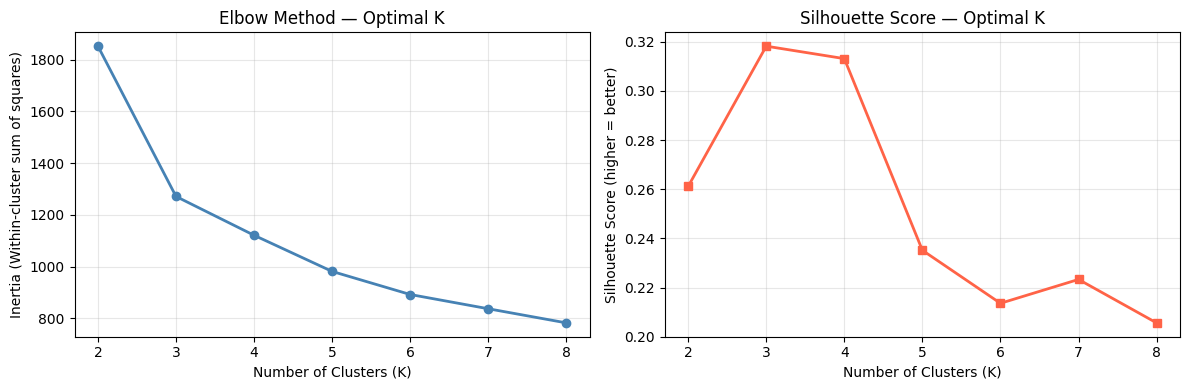

Saved: cluster_selection.png

Best K by Silhouette: 3
Using N_CLUSTERS = 4 (adjust if needed based on plot)

── Step 3: Clustering all windows into 4 clusters ─

Cluster Profiles (Soil Moisture behaviour):
Cluster    Count      Mean SM      Slope        Std          Label
----------------------------------------------------------------------
  C0        4884       0.429599     0.000059     0.112348     Transitioning
  C1        51229      0.435045     -0.000107    0.209311     Transitioning
  C2        11377      0.433749     -0.000002    0.170882     Transitioning
  C3        32271      0.435286     0.000174     0.209996     Transitioning

── Visualising Clusters ──────────────────────────────


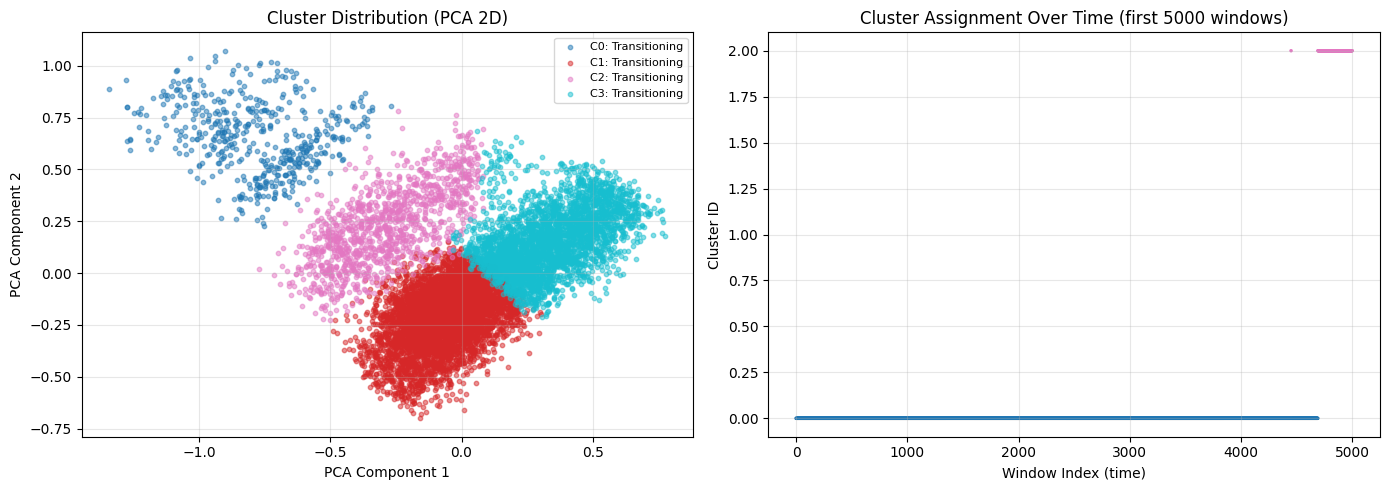

Saved: cluster_visualisation.png

── Cluster Dataset Sizes ─────────────────────────────
  Cluster 0 (Transitioning ): Train=  4783 | Val=   101
  Cluster 1 (Transitioning ): Train= 39747 | Val= 11482
  Cluster 2 (Transitioning ): Train= 10216 | Val=  1161
  Cluster 3 (Transitioning ): Train= 25062 | Val=  7208

── Step 6: Training Specialist Transformers ──────────

  ── Cluster 0 (Transitioning) ────────────────
    Epoch   1/100 | Train: 0.009014 | Val: 0.006591 | 6.6s
    Epoch  10/100 | Train: 0.003535 | Val: 0.007197 | 5.8s
    Epoch  20/100 | Train: 0.003184 | Val: 0.006681 | 6.1s
    Epoch  30/100 | Train: 0.002959 | Val: 0.006822 | 6.1s
    Epoch  40/100 | Train: 0.002961 | Val: 0.006763 | 6.0s
    Epoch  50/100 | Train: 0.002898 | Val: 0.006754 | 6.1s
    Epoch  60/100 | Train: 0.002900 | Val: 0.006751 | 6.0s
    Epoch  70/100 | Train: 0.002899 | Val: 0.006749 | 6.1s
    Epoch  80/100 | Train: 0.002891 | Val: 0.006750 | 6.0s
    Epoch  90/100 | Train: 0.002859 | Val: 0.006752

In [ ]:
# ============================================================
#  CLUSTER-BASED TRANSFORMER — Soil Moisture Forecasting
#  Google Colab Ready | Unsupervised Clustering + Specialist
#  Transformers per Cluster | Autoregressive 14400-step Forecast
# ============================================================

# ── 0. INSTALL / IMPORTS ────────────────────────────────────
!pip install openpyxl scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, mean_squared_error,
                             mean_absolute_error)
from sklearn.decomposition import PCA
import math
import time
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_excel('/content/Final_Dataset.xlsx', engine='openpyxl')
df.columns = df.columns.str.strip()

print(f"Columns : {df.columns.tolist()}")
print(f"Shape   : {df.shape}")
print(df.head(10))


# ============================================================
# 2. PREPROCESSING
# ============================================================
features = df[["IRRIGATION", "Soil Moisture"]].values   # (N, 2)

scaler    = MinMaxScaler()
scaled    = scaler.fit_transform(features)

sm_scaler = MinMaxScaler()
sm_scaler.fit(features[:, 1].reshape(-1, 1))

# ── Hyperparameters ─────────────────────────────────────────
LOOKBACK     = 240
HORIZON      = 1
BATCH_SIZE   = 32
EPOCHS       = 100
PATIENCE     = 20
LR           = 2e-4
D_MODEL      = 128
NHEAD        = 8
NUM_LAYERS   = 4
DIM_FF       = 256
DROPOUT      = 0.08
WEIGHT_DECAY = 5e-6
TRAIN_SPLIT  = 0.8
N_CLUSTERS   = 4

print(f"\nLOOKBACK  : {LOOKBACK} minutes")
print(f"N_CLUSTERS: {N_CLUSTERS}")


# ============================================================
# 3. STEP 1 — FEATURE EXTRACTION FOR CLUSTERING
# ============================================================
# Extract statistical features from each sliding window
# These features describe the "behaviour" of that window
# Used by K-Means to group similar behavioural patterns

print("\n── Step 1: Extracting window features for clustering ─")

CLUSTER_WINDOW = LOOKBACK   # same size as transformer lookback

def extract_features(data_scaled, window_size):
    """
    For each window, extract 10 statistical features:
    mean, std, min, max, range, slope (trend),
    mean_diff (rate of change), skewness, energy, last_value
    These capture the 'behaviour' of each window.
    """
    sm   = data_scaled[:, 1]   # Soil Moisture only for clustering
    irr  = data_scaled[:, 0]   # Irrigation
    n    = len(sm) - window_size + 1
    feats = []

    for i in range(n):
        w     = sm[i : i + window_size]
        irr_w = irr[i : i + window_size]

        mean_sm    = np.mean(w)
        std_sm     = np.std(w)
        min_sm     = np.min(w)
        max_sm     = np.max(w)
        range_sm   = max_sm - min_sm
        # Linear slope (trend direction: positive=rising, negative=dropping)
        slope      = np.polyfit(np.arange(window_size), w, 1)[0]
        mean_diff  = np.mean(np.diff(w))           # average rate of change
        energy     = np.sum(w ** 2) / window_size  # signal energy
        last_val   = w[-1]                         # current moisture level
        mean_irr   = np.mean(irr_w)                # irrigation context

        feats.append([mean_sm, std_sm, min_sm, max_sm, range_sm,
                      slope, mean_diff, energy, last_val, mean_irr])

    return np.array(feats)

all_features = extract_features(scaled, CLUSTER_WINDOW)
print(f"Feature matrix shape: {all_features.shape}")
print(f"Features: mean, std, min, max, range, slope, mean_diff, energy, last_val, mean_irr")

# Normalise features for clustering
feat_scaler   = MinMaxScaler()
feats_scaled  = feat_scaler.fit_transform(all_features)


# ============================================================
# 4. STEP 2 — FIND OPTIMAL NUMBER OF CLUSTERS
# ============================================================
print("\n── Step 2: Finding optimal K (Elbow + Silhouette) ───")

# Use a subset for speed (every 10th window)
sample_idx   = np.arange(0, len(feats_scaled), 10)
feats_sample = feats_scaled[sample_idx]

inertias     = []
sil_scores   = []
K_range      = range(2, 9)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(feats_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(feats_sample, lbl))
    print(f"  K={k} | Inertia: {km.inertia_:.2f} | Silhouette: {sil_scores[-1]:.4f}")

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-cluster sum of squares)")
axes[0].set_title("Elbow Method — Optimal K")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, marker='s', color='tomato', linewidth=2)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].set_title("Silhouette Score — Optimal K")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_selection.png", dpi=150)
plt.show()
print("Saved: cluster_selection.png")

# Auto-select best K by silhouette
best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nBest K by Silhouette: {best_k}")
print(f"Using N_CLUSTERS = {N_CLUSTERS} (adjust if needed based on plot)")


# ============================================================
# 5. STEP 3 — ASSIGN CLUSTERS TO ALL WINDOWS
# ============================================================
print(f"\n── Step 3: Clustering all windows into {N_CLUSTERS} clusters ─")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
all_labels = kmeans.fit_predict(feats_scaled)

# Cluster statistics — understand what each cluster represents
print("\nCluster Profiles (Soil Moisture behaviour):")
print(f"{'Cluster':<10} {'Count':<10} {'Mean SM':<12} {'Slope':<12} {'Std':<12} {'Label'}")
print("-" * 70)

cluster_labels_desc = []
for c in range(N_CLUSTERS):
    idx     = np.where(all_labels == c)[0]
    c_feats = all_features[idx]
    mean_sm = sm_scaler.inverse_transform([[c_feats[:, 0].mean()]])[0][0]
    slope   = c_feats[:, 5].mean()
    std_sm  = c_feats[:, 1].mean()
    count   = len(idx)

    # Auto-label based on slope and std
    if slope > 0.0003:
        desc = "Rising"
    elif slope < -0.0003:
        desc = "Dropping"
    elif std_sm < 0.002:
        desc = "Stable"
    else:
        desc = "Transitioning"

    cluster_labels_desc.append(desc)
    print(f"  C{c:<8} {count:<10} {mean_sm:<12.6f} {slope:<12.6f} {std_sm:<12.6f} {desc}")


# ============================================================
# 6. VISUALISE CLUSTERS (PCA + Time plot)
# ============================================================
print("\n── Visualising Clusters ──────────────────────────────")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = cm.tab10(np.linspace(0, 1, N_CLUSTERS))

# PCA 2D scatter
pca    = PCA(n_components=2)
pca_2d = pca.fit_transform(feats_scaled[sample_idx])

for c in range(N_CLUSTERS):
    mask = all_labels[sample_idx] == c
    axes[0].scatter(pca_2d[mask, 0], pca_2d[mask, 1],
                    c=[colors[c]], label=f"C{c}: {cluster_labels_desc[c]}",
                    alpha=0.5, s=10)
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].set_title("Cluster Distribution (PCA 2D)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Cluster assignment over time (first 5000 windows)
t_range = min(5000, len(all_labels))
axes[1].scatter(range(t_range), all_labels[:t_range],
                c=[colors[l] for l in all_labels[:t_range]],
                s=2, alpha=0.7)
axes[1].set_xlabel("Window Index (time)")
axes[1].set_ylabel("Cluster ID")
axes[1].set_title("Cluster Assignment Over Time (first 5000 windows)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_visualisation.png", dpi=150)
plt.show()
print("Saved: cluster_visualisation.png")


# ============================================================
# 7. STEP 4 — DATASET PER CLUSTER
# ============================================================
# Each cluster gets its own dataset of windows

class ClusterDataset(Dataset):
    """
    Dataset containing only windows belonging to a specific cluster.
    src : (LOOKBACK, 2)  — past [irrigation, soil_moisture]
    tgt : (1,)           — next soil_moisture (normalised)
    """
    def __init__(self, scaled_data, window_indices, lookback, horizon):
        self.scaled_data    = scaled_data
        self.window_indices = window_indices
        self.lookback       = lookback
        self.horizon        = horizon

    def __len__(self):
        valid = [
            idx for idx in self.window_indices
            if idx + self.lookback + self.horizon <= len(self.scaled_data)
        ]
        self.window_indices = np.array(valid)
        return len(self.window_indices)

    def __getitem__(self, i):
        idx = self.window_indices[i]
        src = self.scaled_data[idx : idx + self.lookback]
        tgt = self.scaled_data[idx + self.lookback : idx + self.lookback + self.horizon, 1]
        return (torch.tensor(src, dtype=torch.float32),
                torch.tensor(tgt, dtype=torch.float32))


# Split indices for train/val
split_idx  = int(len(all_labels) * TRAIN_SPLIT)

cluster_loaders = {}   # {cluster_id: (train_loader, val_loader, train_count, val_count)}

print("\n── Cluster Dataset Sizes ─────────────────────────────")
for c in range(N_CLUSTERS):
    c_indices      = np.where(all_labels == c)[0]
    train_idx      = c_indices[c_indices < split_idx]
    val_idx        = c_indices[c_indices >= split_idx]

    train_ds = ClusterDataset(scaled, train_idx, LOOKBACK, HORIZON)
    val_ds   = ClusterDataset(scaled, val_idx,   LOOKBACK, HORIZON)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, drop_last=False)

    cluster_loaders[c] = (train_loader, val_loader, len(train_ds), len(val_ds))
    print(f"  Cluster {c} ({cluster_labels_desc[c]:<14}): "
          f"Train={len(train_ds):6d} | Val={len(val_ds):6d}")


# ============================================================
# 8. STEP 5 — TRANSFORMER MODEL (one per cluster)
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class ClusterTransformer(nn.Module):
    """
    Vanilla Transformer — one instance trained per cluster.
    Each model specialises in the behaviour of its cluster:
      C0: Expert at Rising moisture patterns
      C1: Expert at Stable moisture patterns
      C2: Expert at Dropping moisture patterns
      C3: Expert at Transitioning patterns
    """
    def __init__(self, input_dim=2, d_model=D_MODEL, nhead=NHEAD,
                 num_layers=NUM_LAYERS, dim_ff=DIM_FF,
                 dropout=DROPOUT, horizon=HORIZON, cluster_id=0):
        super().__init__()
        self.cluster_id  = cluster_id
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.pos_enc     = PositionalEncoding(d_model, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True
        )
        self.encoder     = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.output_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, horizon)
        )

    def forward(self, src):
        x   = self.input_proj(src)
        x   = self.pos_enc(x)
        x   = self.encoder(x)
        out = self.output_head(x[:, -1, :])
        return out


# ============================================================
# 9. STEP 6 — TRAIN ONE TRANSFORMER PER CLUSTER
# ============================================================
print("\n── Step 6: Training Specialist Transformers ──────────")

cluster_models      = {}
cluster_train_hist  = {}
cluster_val_hist    = {}

for c in range(N_CLUSTERS):
    print(f"\n  ── Cluster {c} ({cluster_labels_desc[c]}) ────────────────")

    train_loader, val_loader, n_train, n_val = cluster_loaders[c]

    if n_train < BATCH_SIZE:
        print(f"  ⚠️  Cluster {c} has too few samples ({n_train}), skipping training.")
        cluster_models[c] = None
        continue

    model     = ClusterTransformer(cluster_id=c).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    best_val  = float("inf")
    t_losses, v_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        # Train
        model.train()
        run_loss = 0.0
        for src, tgt in train_loader:
            src, tgt = src.to(device), tgt.to(device)
            optimizer.zero_grad()
            pred = model(src)
            loss = criterion(pred, tgt)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            run_loss += loss.item()
        train_loss = run_loss / len(train_loader)

        # Validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                val_loss += criterion(model(src), tgt).item()
        val_loss /= max(len(val_loader), 1)

        scheduler.step(val_loss)
        t_losses.append(train_loss)
        v_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), f"best_cluster_{c}.pt")

        if epoch % 10 == 0 or epoch == 1:
            print(f"    Epoch {epoch:3d}/{EPOCHS} | "
                  f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
                  f"{time.time()-t0:.1f}s")

    print(f"  Best Val Loss: {best_val:.6f}")

    # Load best weights
    model.load_state_dict(torch.load(f"best_cluster_{c}.pt"))
    cluster_models[c]     = model
    cluster_train_hist[c] = t_losses
    cluster_val_hist[c]   = v_losses


# ============================================================
# 10. PLOT TRAINING CURVES (all clusters)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for c in range(N_CLUSTERS):
    if c not in cluster_train_hist:
        continue
    axes[c].plot(cluster_train_hist[c], label="Train", color="steelblue")
    axes[c].plot(cluster_val_hist[c],   label="Val",   color="tomato")
    axes[c].set_title(f"Cluster {c}: {cluster_labels_desc[c]}")
    axes[c].set_xlabel("Epoch")
    axes[c].set_ylabel("MSE Loss")
    axes[c].legend()
    axes[c].grid(True, alpha=0.3)

plt.suptitle("Cluster-Based Transformer — Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cluster_training_curves.png", dpi=150)
plt.show()
print("Saved: cluster_training_curves.png")


# ============================================================
# 11. STEP 7 — CLUSTER ROUTING FUNCTION
# ============================================================
def get_cluster(window_scaled):
    """
    Given a new window of scaled data (LOOKBACK, 2),
    extract features and determine which cluster it belongs to.
    Returns cluster_id (int).
    """
    w       = window_scaled[:, 1]           # Soil Moisture
    irr_w   = window_scaled[:, 0]           # Irrigation
    L       = len(w)

    mean_sm  = np.mean(w)
    std_sm   = np.std(w)
    min_sm   = np.min(w)
    max_sm   = np.max(w)
    range_sm = max_sm - min_sm
    slope    = np.polyfit(np.arange(L), w, 1)[0]
    mean_diff= np.mean(np.diff(w))
    energy   = np.sum(w ** 2) / L
    last_val = w[-1]
    mean_irr = np.mean(irr_w)

    feat = np.array([[mean_sm, std_sm, min_sm, max_sm, range_sm,
                      slope, mean_diff, energy, last_val, mean_irr]])
    feat_norm = feat_scaler.transform(feat)
    return int(kmeans.predict(feat_norm)[0])


# ============================================================
# 12. STEP 8 — EVALUATION ON VALIDATION SET (per cluster + overall)
# ============================================================
print("\n── Step 8: Evaluation on Validation Set ─────────────")

all_preds_combined   = []
all_targets_combined = []
cluster_metrics      = {}

for c in range(N_CLUSTERS):
    model = cluster_models.get(c)
    if model is None:
        continue

    _, val_loader, _, n_val = cluster_loaders[c]
    if n_val == 0:
        continue

    model.eval()
    c_preds, c_targets = [], []

    with torch.no_grad():
        for src, tgt in val_loader:
            src    = src.to(device)
            pred   = model(src).cpu().numpy()
            c_preds.append(pred)
            c_targets.append(tgt.numpy())

    c_preds   = np.concatenate(c_preds,   axis=0).reshape(-1, 1)
    c_targets = np.concatenate(c_targets, axis=0).reshape(-1, 1)

    p_inv = sm_scaler.inverse_transform(c_preds).flatten()
    t_inv = sm_scaler.inverse_transform(c_targets).flatten()

    all_preds_combined.extend(p_inv)
    all_targets_combined.extend(t_inv)

    mse  = mean_squared_error(t_inv, p_inv)
    mae  = mean_absolute_error(t_inv, p_inv)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((t_inv - p_inv) / (t_inv + 1e-8))) * 100
    ss_r = np.sum((t_inv - p_inv) ** 2)
    ss_t = np.sum((t_inv - t_inv.mean()) ** 2)
    r2   = 1 - (ss_r / (ss_t + 1e-8))
    naive_mae = np.mean(np.abs(np.diff(t_inv)))
    mase = mae / (naive_mae + 1e-8)

    cluster_metrics[c] = dict(mse=mse, rmse=rmse, mae=mae,
                               mape=mape, r2=r2, mase=mase)

    print(f"\n  Cluster {c} ({cluster_labels_desc[c]}) — n={n_val}")
    print(f"    RMSE : {rmse:.8f}")
    print(f"    MAE  : {mae:.8f}")
    print(f"    MAPE : {mape:.4f} %")
    print(f"    R²   : {r2:.6f}")
    print(f"    MASE : {mase:.6f}")

# ── Overall metrics ──────────────────────────────────────────
all_p = np.array(all_preds_combined)
all_t = np.array(all_targets_combined)

overall_mse  = mean_squared_error(all_t, all_p)
overall_mae  = mean_absolute_error(all_t, all_p)
overall_rmse = np.sqrt(overall_mse)
overall_mape = np.mean(np.abs((all_t - all_p) / (all_t + 1e-8))) * 100
ss_r = np.sum((all_t - all_p) ** 2)
ss_t = np.sum((all_t - all_t.mean()) ** 2)
overall_r2   = 1 - (ss_r / (ss_t + 1e-8))
naive_mae    = np.mean(np.abs(np.diff(all_t)))
overall_mase = overall_mae / (naive_mae + 1e-8)

print(f"\n── Overall Validation Metrics (all clusters combined) ─")
print(f"  MSE          : {overall_mse:.8f}")
print(f"  RMSE         : {overall_rmse:.8f}")
print(f"  MAE          : {overall_mae:.8f}")
print(f"  MAPE         : {overall_mape:.4f} %")
print(f"  Standard R²  : {overall_r2:.6f}")
print(f"  MASE         : {overall_mase:.6f}")

if overall_mase < 1.0:
    print(f"  ✅ Model beats naive baseline (MASE < 1)")
else:
    print(f"  ⚠️  Model worse than naive baseline (MASE > 1)")

if overall_r2 > 0.9:
    print(f"  ✅ Strong fit (R² > 0.9)")
elif overall_r2 > 0.7:
    print(f"  ⚠️  Moderate fit (R² 0.7–0.9)")
else:
    print(f"  ❌ Weak fit (R² < 0.7)")

# ── Dynamic R² ───────────────────────────────────────────────
window_size = 1440
dynamic_r2  = []
for i in range(0, len(all_t) - window_size, window_size):
    yt = all_t[i : i + window_size]
    yp = all_p[i : i + window_size]
    ss_r_w = np.sum((yt - yp) ** 2)
    ss_t_w = np.sum((yt - yt.mean()) ** 2)
    dynamic_r2.append(1 - (ss_r_w / (ss_t_w + 1e-8)))

dynamic_r2 = np.array(dynamic_r2)
print(f"\n── Dynamic R² (Rolling 1-day window) ────────────────")
print(f"  Mean  : {dynamic_r2.mean():.6f}")
print(f"  Min   : {dynamic_r2.min():.6f}")
print(f"  Max   : {dynamic_r2.max():.6f}")

# ── Evaluation plots ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Actual vs Predicted
axes[0].plot(all_t[:1000], label="Actual",    color="steelblue", linewidth=1)
axes[0].plot(all_p[:1000], label="Predicted", color="tomato",    linewidth=1, alpha=0.8)
axes[0].set_title("Cluster-Based Transformer — Actual vs Predicted (first 1000 steps)")
axes[0].set_xlabel("Time Step (min)")
axes[0].set_ylabel("Soil Moisture")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = all_t[:1000] - all_p[:1000]
axes[1].plot(residuals, color="darkorange", linewidth=0.8)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Residuals (Actual − Predicted)")
axes[1].set_xlabel("Time Step (min)")
axes[1].set_ylabel("Residual")
axes[1].grid(True, alpha=0.3)

# Plot 3: Dynamic R²
axes[2].plot(dynamic_r2, color="purple", linewidth=1)
axes[2].axhline(0.9, color="green", linestyle="--", linewidth=0.8, label="0.9 threshold")
axes[2].axhline(0.0, color="red",   linestyle="--", linewidth=0.8, label="0.0 baseline")
axes[2].set_title("Dynamic R² Over Time (Rolling 1-Day Window)")
axes[2].set_xlabel("Window Index (each = 1 day)")
axes[2].set_ylabel("R²")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_evaluation.png", dpi=150)
plt.show()
print("Saved: cluster_evaluation.png")


# ============================================================
# 13. STEP 9 — AUTOREGRESSIVE FORECAST (14,400 steps)
# ============================================================
print("\n── Step 9: Generating 14,400-step Forecast ──────────")

seed_window        = scaled[-LOOKBACK:].copy()
mean_irr_scaled    = scaled[:, 0].mean()
forecast_sm_scaled = []
forecast_clusters  = []

# ── Smoothing parameters ─────────────────────────────────────
SMOOTH_WINDOW   = 5       # rolling average window for transition smoothing
prev_cluster    = None    # track previous cluster for handoff detection
raw_forecast    = []      # store raw predictions before smoothing

with torch.no_grad():
    window = seed_window.copy()

    for step in range(14400):
        # Route to correct cluster
        c_id  = get_cluster(window)

        # ── Transition dampening ─────────────────────────────
        # When cluster changes, blend prediction with last prediction
        # to avoid abrupt jumps at handoff boundaries
        if prev_cluster is not None and c_id != prev_cluster:
            # Cluster switched — get prediction from BOTH old and new cluster
            model_new  = cluster_models.get(c_id)
            model_prev = cluster_models.get(prev_cluster)

            if model_new is None:
                model_new = cluster_models.get(0)
            if model_prev is None:
                model_prev = cluster_models.get(0)

            src = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)

            pred_new  = model_new(src).cpu().numpy()[0, 0]
            pred_prev = model_prev(src).cpu().numpy()[0, 0]

            # Blend: 70% new cluster, 30% old cluster at handoff point
            pred_scaled = 0.7 * pred_new + 0.3 * pred_prev

        else:
            # Same cluster — use specialist directly
            model = cluster_models.get(c_id)
            if model is None:
                model = cluster_models.get(0)

            src         = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
            pred_scaled = model(src).cpu().numpy()[0, 0]

        raw_forecast.append(pred_scaled)
        forecast_clusters.append(c_id)
        prev_cluster = c_id

        new_row = np.array([mean_irr_scaled, pred_scaled])
        window  = np.vstack([window[1:], new_row])

        if (step + 1) % 1440 == 0:
            day = (step + 1) // 1440
            c_counts = [forecast_clusters[-1440:].count(cc)
                        for cc in range(N_CLUSTERS)]
            print(f"  Day {day:2d} complete | Cluster usage: "
                  + " | ".join([f"C{cc}:{c_counts[cc]}" for cc in range(N_CLUSTERS)]))

# ── Post-forecast smoothing (rolling average) ─────────────────
# Applies a light rolling average to remove cluster-handoff spikes
# while preserving the overall trend shape
raw_forecast = np.array(raw_forecast)

smoothed = np.convolve(
    raw_forecast,
    np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW,
    mode='same'
)

# Edge correction — convolution shrinks edges, restore with raw values
half = SMOOTH_WINDOW // 2
smoothed[:half] = raw_forecast[:half]
smoothed[-half:] = raw_forecast[-half:]

forecast_sm_scaled = smoothed.reshape(-1, 1)
forecast_sm        = sm_scaler.inverse_transform(forecast_sm_scaled).flatten()

print(f"\nForecast Summary (Soil Moisture):")
print(f"  Min  : {forecast_sm.min():.6f}")
print(f"  Max  : {forecast_sm.max():.6f}")
print(f"  Mean : {forecast_sm.mean():.6f}")
print(f"  Std  : {forecast_sm.std():.6f}")

# Forecast stability score
historical_std  = np.std(features[:, 1])
forecast_std    = np.std(forecast_sm)
stability_score = forecast_std / (historical_std + 1e-8)
print(f"\nForecast Stability Score : {stability_score:.4f}  (1.0 = ideal)")
print(f"Smoothing Window Applied : {SMOOTH_WINDOW} steps")


# ============================================================
# 14. PLOT 10-DAY FORECAST
# ============================================================
days = np.arange(1, 14401) / 1440

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Full 10-day forecast
axes[0].plot(days, forecast_sm, color="seagreen", linewidth=0.8)
axes[0].set_xlabel("Days Ahead")
axes[0].set_ylabel("Soil Moisture")
axes[0].set_title("Cluster-Based Transformer — 10-Day Soil Moisture Forecast")
axes[0].set_xticks(range(0, 11))
axes[0].grid(True, alpha=0.3)

# Plot 2: Historical + forecast continuity
last_actual = all_t[-500:]
combined_x  = np.arange(-len(last_actual), 14400)
axes[1].plot(combined_x[:len(last_actual)], last_actual,
             color="steelblue", label="Historical (last 500 min)", linewidth=1)
axes[1].plot(combined_x[len(last_actual):], forecast_sm,
             color="tomato",    label="Forecast (14,400 min)",     linewidth=0.8)
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1, label="Forecast start")
axes[1].set_xlabel("Minutes (0 = forecast start)")
axes[1].set_ylabel("Soil Moisture")
axes[1].set_title("Historical Continuation → 10-Day Forecast")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Cluster routing over forecast
colors_list = cm.tab10(np.linspace(0, 1, N_CLUSTERS))
for c in range(N_CLUSTERS):
    mask = np.array(forecast_clusters) == c
    x_c  = np.where(mask)[0]
    axes[2].scatter(x_c / 1440, [c] * len(x_c),
                    c=[colors_list[c]], s=1,
                    label=f"C{c}: {cluster_labels_desc[c]}")
axes[2].set_xlabel("Days Ahead")
axes[2].set_ylabel("Cluster Used")
axes[2].set_title("Cluster Routing During Forecast (which specialist was used)")
axes[2].set_yticks(range(N_CLUSTERS))
axes[2].set_yticklabels([f"C{c}: {cluster_labels_desc[c]}" for c in range(N_CLUSTERS)])
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_forecast_10days.png", dpi=150)
plt.show()
print("Saved: cluster_forecast_10days.png")


# ============================================================
# 15. FINAL COMPARISON — CLUSTER vs GLOBAL MODELS
# ============================================================
print("\n── Final Model Comparison ────────────────────────────")
print(f"{'Metric':<20} {'Vanilla':>12} {'PatchTST':>12} {'iTransformer':>14} {'Cluster-Based':>15}")
print("-" * 75)

metrics_table = [
    ("RMSE",       0.002536, 0.002589, 0.002572, overall_rmse),
    ("MAE",        0.000899, 0.001009, 0.001104, overall_mae),
    ("MAPE (%)",   0.2058,   0.2314,   0.2526,   overall_mape),
    ("R²",         0.8914,   0.8873,   0.8888,   overall_r2),
    ("MASE",       1.034,    1.159,    1.269,    overall_mase),
    ("Dyn R² Mean",0.8907,   0.8860,   0.8878,   dynamic_r2.mean()),
]

for name, v, p, it, cb in metrics_table:
    best = min([v, p, it, cb]) if name != "R²" else max([v, p, it, cb])
    best = min([v, p, it, cb]) if "Dyn" not in name and name != "R²" else best
    print(f"  {name:<18} {v:>12.6f} {p:>12.6f} {it:>14.6f} {cb:>15.6f}"
          + (" ✅" if cb == best else ""))


# ============================================================
# 16. SAVE FORECAST TO CSV
# ============================================================
forecast_df = pd.DataFrame({
    "Minute"         : np.arange(1, 14401),
    "Forecast_SM"    : forecast_sm,
    "Cluster_Used"   : forecast_clusters
})
forecast_df.to_csv("forecast_14400_cluster_transformer.csv", index=False)
print("\nForecast saved to: forecast_14400_cluster_transformer.csv")
print(forecast_df.head(10))
print("\n── Done ──────────────────────────────────────────────")